# Una scimmia, un punteruolo ed il $\pi$ greco.

Utilizzeremo un noto esempio didattico di introduzione al metodo [Monte Carlo](https://it.wikipedia.org/wiki/Metodo_Monte_Carlo), per calcolare il valore di $\pi$. L'esempio in questione è quello detto della "scimmia e del punteruolo". Sostanzialmente questo esempio immagina di dover calcolare l'area di una certa superficie sfruttando una scimmia con un punteruolo...si ok...fidatevi.
Come funziona questo metodo bizzarro? L'ipotesi è che io in generale non sappia determinare questa superficie normalmente, come farei normalmente conoscendo la geometria. Questo è piuttosto vero per superfici irregolari, tipo una macchia. Per dimostrare il metodo di solito si usa invece una superficie facilissima da calcolare: la cirfonferenza. Questo perché così si può verificare la validità del metodo, confrontando il risultato ottenuto con quello del semplice calcolo geometrico dell'area di una circonferenza, ossia:
$$
A_{\bigcirc} = \pi \cdot r^2
$$
Il metodo è semplice. Si immagina di disegnare un cerchio di raggio $r$ su di un foglio quadrato di cui conosciamo il lato $l$. Dopodichè si da il foglio ad una scimmia dotata di punteruolo. Se questa non dovesse scegliere di fare altro o disinteressarsi al nostro metodo, potrebbe iniziare a bucherellare il foglio col punteruolo...con buona probabilità in modo completamente casuale fino a stufarsi. E' ragionevole aspettarsi che, se i buchi sono stati fatti veramente a caso, il numero $N_q$ di questi all'interno del quadrato siano proporzionali alla sua area $A_{\Box}$. Stesso discorso per i $N_c$ buchi fatti all'interno della circonferenza, che saranno proporzionali all'area $A_{\bigcirc}$. Chiaramente più buchi vengono fatti più questa cosa è vera. Allora sarà anche vero che il rapporto $\rho_N$ tra questi numeri, per un numero totale di buchi $N$ molto grande, tenderà al rapporto tra le aree. Cioè:
$$
\lim_{N\rightarrow \infty}{\rho_N}=\frac{A_{\bigcirc}}{A_{\Box}}
$$
Quindi per un numero sufficientemente grande di buchi, posso scrivere:
$$
\rho_N=\frac{A_{\bigcirc}}{A_{\Box}}=\frac{\pi \cdot r^2}{l^2}
$$
Da cui segue che, calcolando $\rho_N$, posso calcolarmi un valore approssimato di $\pi$ che sarà sempre più preciso quanto più grande è $N$:
$$
\pi=\rho_N \cdot \left(\frac{l}{r}\right)^2
$$
Non potendo disporre di un punteruolo e tantomeno di una scimmia, facciamo fare questo sporco lavoro ad un computer. Useremo per questo scopo il linguaggio di programmazione Python. Anzitutto quindi importiamo le librerie che ci servono:

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display, Latex

Definiamo il numero di punti che vogliamo simulare:

In [6]:
# Number of points
N = 500

Di seguito invece definiamo le variabili che ci servono per descrivere il sistema da simulare, cioè un foglio quadrato di lato `square_side`, sul quale c'è disegnato un cerchio di raggio `radius`. Oltre a questo abbiamo bisogno di definire una funzione che simuli la scimmia, ossia che distribuisca in modo casuale i punti sul foglio. Oltre a questo la funzione, che abbiamo chiamato `monkey_strikes`, calcola quanti buchi sono stati fatti all'interno del foglio e quanti all'interno della circonferenza, restituendoci direttamente il rapporto tra di loro. Proprio $\rho_N$ che vogliamo!

In [16]:
# Defines variables
xps = []
yps = []
xpc = []
ypc = []
square_side = 18
radius = 6
center_x = 10
center_y = 10

def monkey_strikes(N,center_x,center_y,):
    points_in_circle = 0
    points_in_square = 0
    for p in np.arange(0,N,1):
        
        # Generates random point
        xp = random.uniform(1,19)
        yp = random.uniform(1,19)
        
        # Checks if point hits the circle or not
        if ((xp - center_x)**2 + (yp - center_y)**2 <= radius**2):
            points_in_circle = points_in_circle + 1
            xpc.append(xp)
            ypc.append(yp)
        else:
            points_in_square = points_in_square + 1
            xps.append(xp)
            yps.append(yp)
    
    # Calculates the number of points ratio and the area of circle
    points_ratio =  points_in_circle / (points_in_square + points_in_circle)
    return points_ratio

A questo punto è sufficiente richiamare la funzione per fargli calcolare $\rho_N$ ed usarlo per calcolare $\pi$.

In [17]:
points_ratio = monkey_strikes(N,center_x,center_y)

# Calculates pi
pi = points_ratio*(square_side/radius)**2

Non ci manca che visualizzare il foglio bucherellato, (dove sono evidenziati in rosso i punti all'interno della circonferenza) e fargli stampare il risultato. Questo è anche messo a confronto con il valore vero. Potrete provare voi stessi che, aumentando $N$, il valore calcolato di $\pi$ si avvicina sempre più a quello vero.

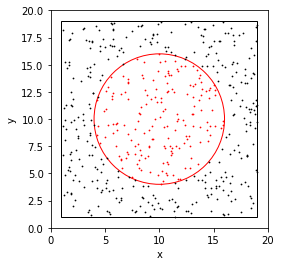

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [18]:
# Plots
fig1 = plt.figure()
ax1 = fig1.add_subplot(111, aspect='equal')
ax1.add_patch(
    patches.Rectangle(
        (1, 1),               # (x,y)
        square_side,          # width
        square_side,          # height
        fill=False            # remove background
    )
)
plt.plot(xps,yps,'k.',ms=1.5)
plt.plot(xpc,ypc,'r.',ms=1.5)
plt.axis([0,20,0,20])
circle = plt.Circle((center_x,center_y),radius, color='r', fill=False)
plt.gcf().gca().add_artist(circle)
plt.xlabel('x')
plt.ylabel('y')
plt.show()


# Prints result
display(Latex(r'Numero di buchi fatti dalla scimmia: '+np.str(N)),\
    Latex(r'Valore calcolato di $\pi = \;$'+np.str(pi)),\
    Latex(r'Valore vero di $\pi = \;$'+np.str(np.pi)))